In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 1: Import Libraries

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

Step 2: Dataset Path

In [51]:
train_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing'
test_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Training'
IMAGE_SIZE = 128

Step 3: Load Dataset

In [52]:
import os

def load_data(directory):
    paths, labels = [], []
    for label in os.listdir(directory):
        for img in os.listdir(os.path.join(directory, label)):
            paths.append(os.path.join(directory, label, img))
            labels.append(label)
    return paths, labels

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

Step 4: Encode Labels

In [53]:
classes = sorted(os.listdir(train_dir))

def encode(labels):
    return np.array([classes.index(l) for l in labels])

Step 5: Preprocess Images

In [54]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def process(paths):
    data = []
    for p in paths:
        img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img) / 255.0
        data.append(img)
    return np.array(data)

X_train = process(train_paths)
y_train = encode(train_labels)

X_test = process(test_paths)
y_test = encode(test_labels)

Step 6: Build ResNet50 Model

In [55]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

base_model = ResNet50(weights='imagenet',
                      include_top=False,
                      input_shape=(128,128,3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Fine-tune last layers
for layer in base_model.layers[-10:]:
    layer.trainable = True

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

Step 7: Compile Model

In [56]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Step 8: Train Model

In [57]:
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.5898 - loss: 1.0188 - val_accuracy: 0.0000e+00 - val_loss: 3.2460
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.7141 - loss: 0.6843 - val_accuracy: 0.0000e+00 - val_loss: 3.8665
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.7609 - loss: 0.5697 - val_accuracy: 0.0000e+00 - val_loss: 4.6025
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8148 - loss: 0.4788 - val_accuracy: 0.0000e+00 - val_loss: 5.4200
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.8289 - loss: 0.3994 - val_accuracy: 0.0000e+00 - val_loss: 5.1478


Step 9: Accuracy & Loss Graph

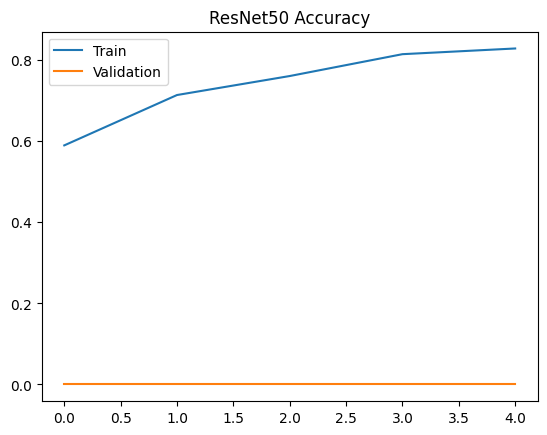

In [58]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ResNet50 Accuracy")
plt.legend(["Train","Validation"])
plt.show()

Step 10: Prediction

In [59]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step


Step 11: Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_classes))

Accuracy & Loss Over Epochs

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Accuracy & Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

Step 12: Confusion Matrix

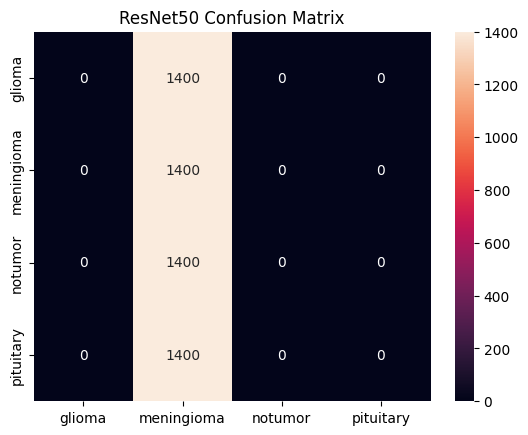

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_classes)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)

plt.title("ResNet50 Confusion Matrix")
plt.show()

In [66]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Accuracy
acc = accuracy_score(y_test, pred_classes)

# F1 Score (choose type based on your problem)
f1 = f1_score(y_test, pred_classes, average='weighted')
# use 'macro' if classes are balanced

print("Accuracy:", acc)
print("F1 Score:", f1)

# Optional (very useful for report)
print("\nClassification Report:\n")
print(classification_report(y_test, pred_classes, target_names=classes))

Accuracy: 0.25
F1 Score: 0.1

Classification Report:

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00      1400
  meningioma       0.25      1.00      0.40      1400
     notumor       0.00      0.00      0.00      1400
   pituitary       0.00      0.00      0.00      1400

    accuracy                           0.25      5600
   macro avg       0.06      0.25      0.10      5600
weighted avg       0.06      0.25      0.10      5600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Final Model Test Accuracy Visualization

175/175 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.2500 - loss: 2.6024


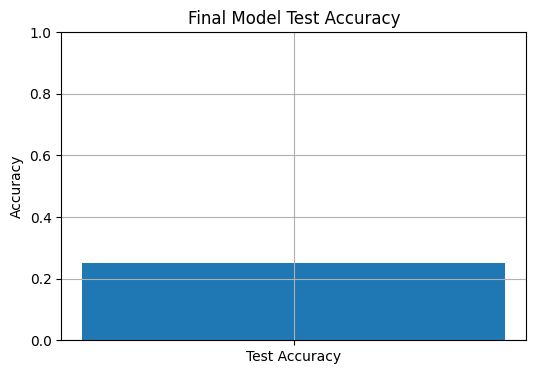

Test Accuracy: 0.25


In [63]:
test_loss, test_acc = model.evaluate(X_test, y_test)

plt.figure(figsize=(6,4))
plt.bar(["Test Accuracy"], [test_acc])
plt.ylim(0, 1)
plt.title("Final Model Test Accuracy")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

print("Test Accuracy:", test_acc)

Step 13: ROC Curve

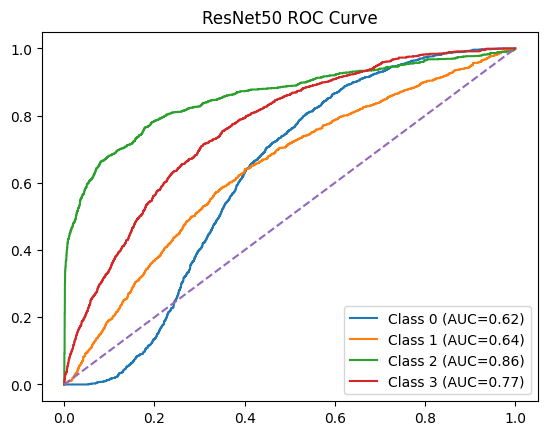

In [64]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ResNet50 ROC Curve")
plt.show()

Step 14: Save Model

In [65]:
model.save("resnet50_model.h5")